In [ ]:
!pip install neo4j
!pip install networkx pyvis

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 325.3/325.3 kB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 29.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 93.4 MB/s eta 0:00:00


In [ ]:
from neo4j import GraphDatabase

print("Neo4j driver imported successfully ✅")

Neo4j driver imported successfully ✅


✅ Loaded 114 triplets


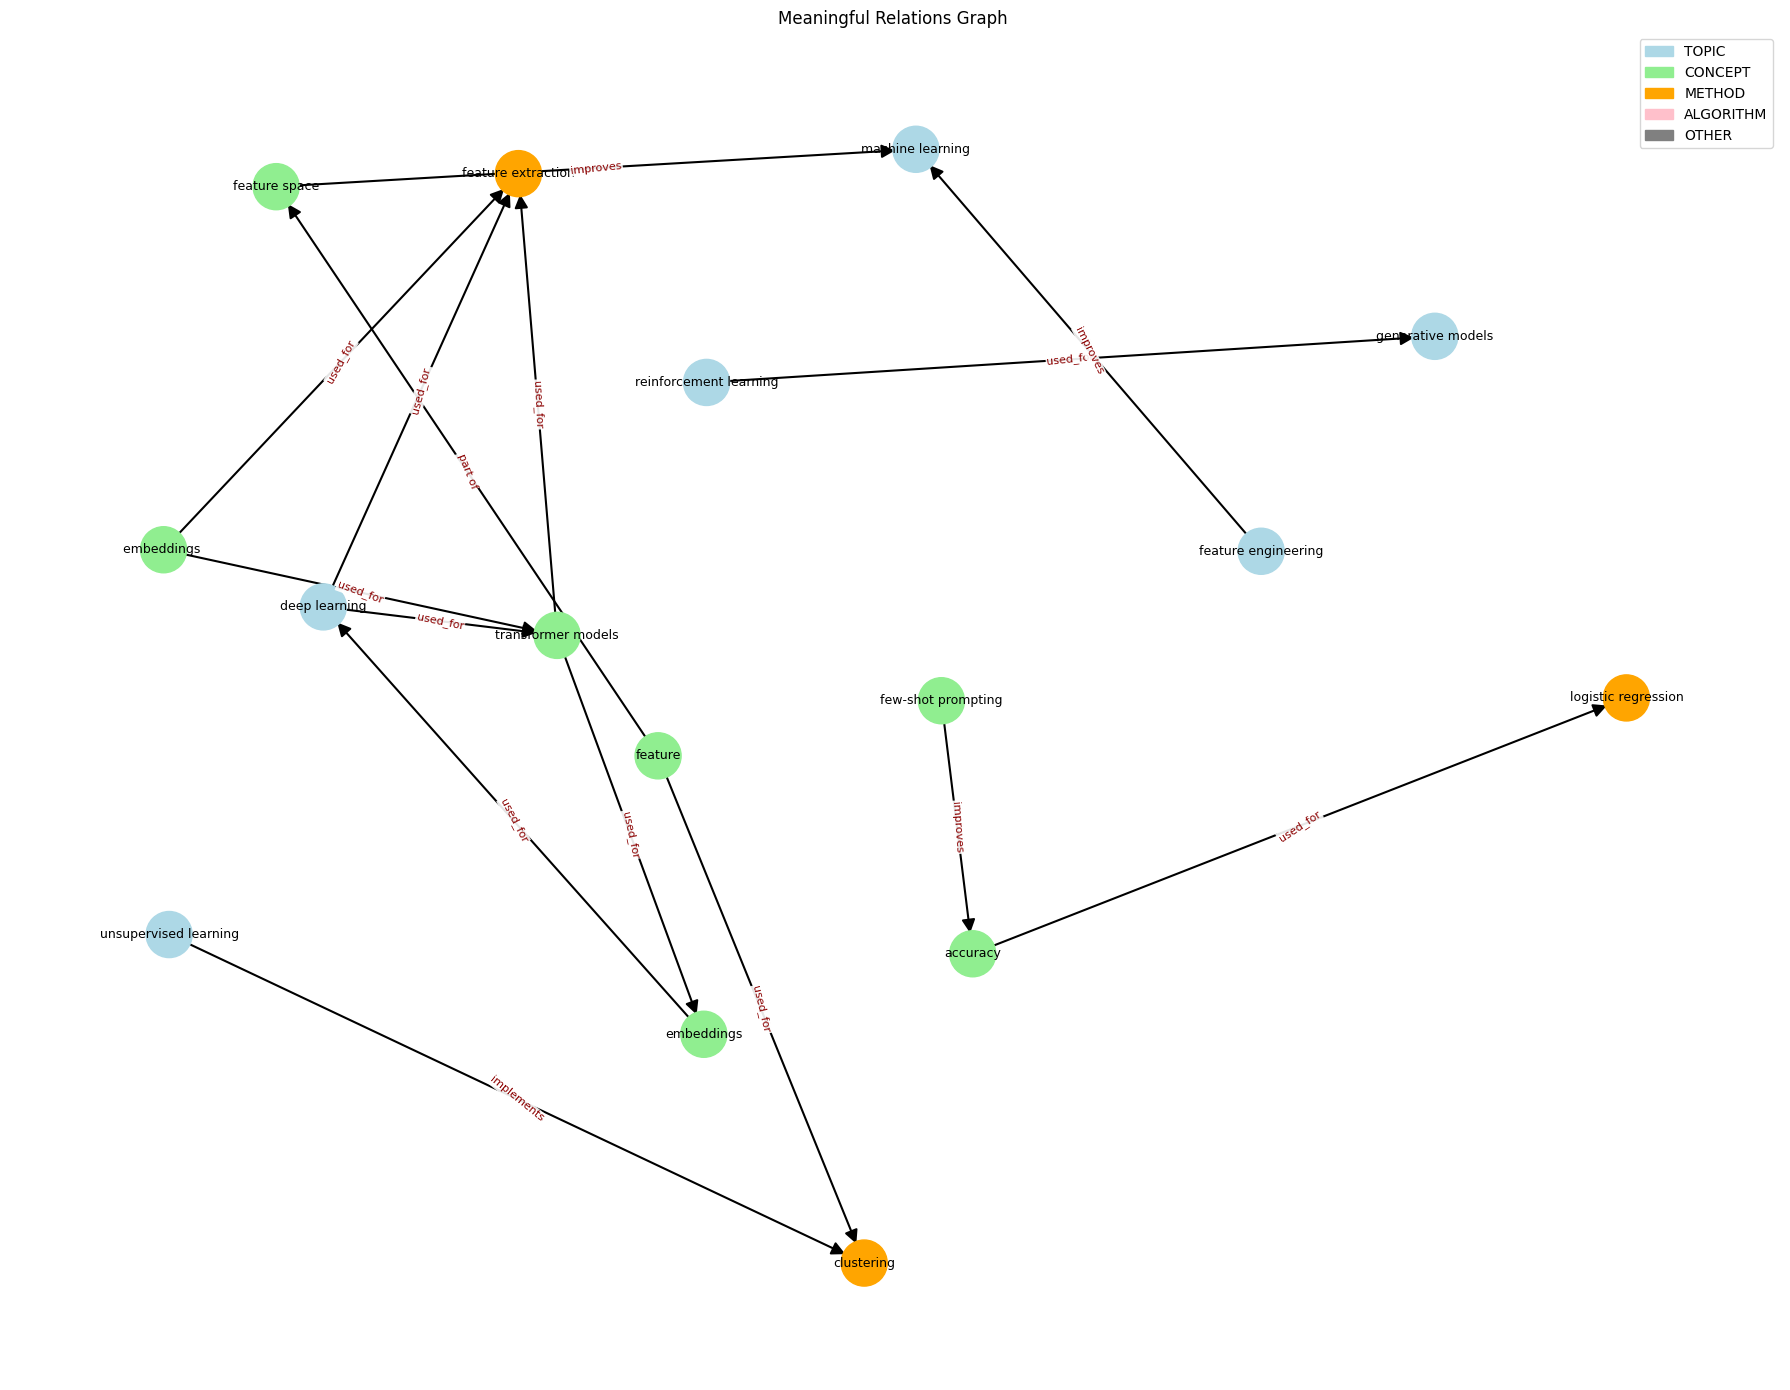

In [19]:
# =========================================
# 1️⃣ IMPORTS
# =========================================
import json
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import math
import random

# =========================================
# 2️⃣ LOAD TRIPLETS
# =========================================
with open("/content/final_triplets_level2.json") as f:
    triplets = json.load(f)

print(f"✅ Loaded {len(triplets)} triplets")

# =========================================
# 3️⃣ MAIN GRAPH (NO part_of)
# =========================================
main_triplets = [t for t in triplets if t["relation"] != "part_of"]

if len(main_triplets) < 10:
    main_triplets = triplets[:30]

MAX_EDGES = 25
main_triplets = main_triplets[:MAX_EDGES]

# =========================================
# 4️⃣ BUILD GRAPH
# =========================================
G_main = nx.DiGraph()

for t in main_triplets:
    G_main.add_node(t["entity1"], label=t["entity1_type"])
    G_main.add_node(t["entity2"], label=t["entity2_type"])
    G_main.add_edge(t["entity1"], t["entity2"], relation=t["relation"])

# =========================================
# 5️⃣ REMOVE HUB NODES (OPTIONAL)
# =========================================
for node in list(G_main.nodes()):
    if G_main.degree(node) > 6:
        G_main.remove_node(node)

# =========================================
# ✅ 6️⃣ REMOVE ISOLATED NODES (NO RELATIONS)
# =========================================
isolated_nodes = list(nx.isolates(G_main))
G_main.remove_nodes_from(isolated_nodes)

# =========================================
# 7️⃣ COLOR MAP
# =========================================
color_map = {
    "TOPIC": "lightblue",
    "CONCEPT": "lightgreen",
    "METHOD": "orange",
    "ALGORITHM": "pink",
    "OTHER": "gray"
}

node_colors = [
    color_map.get(G_main.nodes[n].get("label", "OTHER"), "gray")
    for n in G_main.nodes()
]

# =========================================
# 8️⃣ LAYOUT
# =========================================
pos = nx.spring_layout(G_main, k=2.5, iterations=150, seed=42)

# =========================================
# 9️⃣ DRAW GRAPH
# =========================================
plt.figure(figsize=(18, 14))

nx.draw_networkx_nodes(
    G_main, pos,
    node_color=node_colors,
    node_size=1100
)

nx.draw_networkx_edges(
    G_main,
    pos,
    edgelist=G_main.edges(),
    arrows=True,
    arrowstyle='-|>',
    arrowsize=20,
    width=1.5,
    edge_color="black",
    connectionstyle="arc3,rad=0.0",
    min_source_margin=15,
    min_target_margin=15
)

nx.draw_networkx_labels(
    G_main, pos,
    font_size=9
)

# =========================================
# 🔥 EDGE LABELS EXACTLY ON LINES
# =========================================
for (u, v, d) in G_main.edges(data=True):
    x1, y1 = pos[u]
    x2, y2 = pos[v]

    mx = (x1 + x2) / 2
    my = (y1 + y2) / 2

    angle = math.degrees(math.atan2(y2 - y1, x2 - x1))

    if angle > 90 or angle < -90:
        angle += 180

    plt.text(
        mx,
        my,
        d["relation"],
        fontsize=8,
        color="darkred",
        ha='center',
        va='center',
        rotation=angle,
        rotation_mode='anchor',
        bbox=dict(
            facecolor='white',
            alpha=0.9,
            edgecolor='none',
            pad=0.8
        )
    )

# =========================================
# 🔟 LEGEND
# =========================================
legend_handles = [
    mpatches.Patch(color=color_map[k], label=k)
    for k in color_map
]

plt.legend(handles=legend_handles, loc="best")

# =========================================
# 1️⃣1️⃣ FINAL
# =========================================
plt.title("Meaningful Relations Graph ")
plt.axis("off")
plt.tight_layout()
plt.show()

Original triplets: 114
Removed self-loops: 1
Remaining triplets: 113
REMOVED: {'text': 'overfitting occurs when a generative model memorizes training data instead of learning patterns a key subtopic is generalization which ensures the model can generate new and diverse samples techniques like dropout batch normalization and data augmentation are used to prevent overfitting', 'entity1': 'overfitting', 'entity1_type': 'CONCEPT', 'relation': 'improves', 'entity2': 'overfitting', 'entity2_type': 'CONCEPT', 'confidence': 0.821}


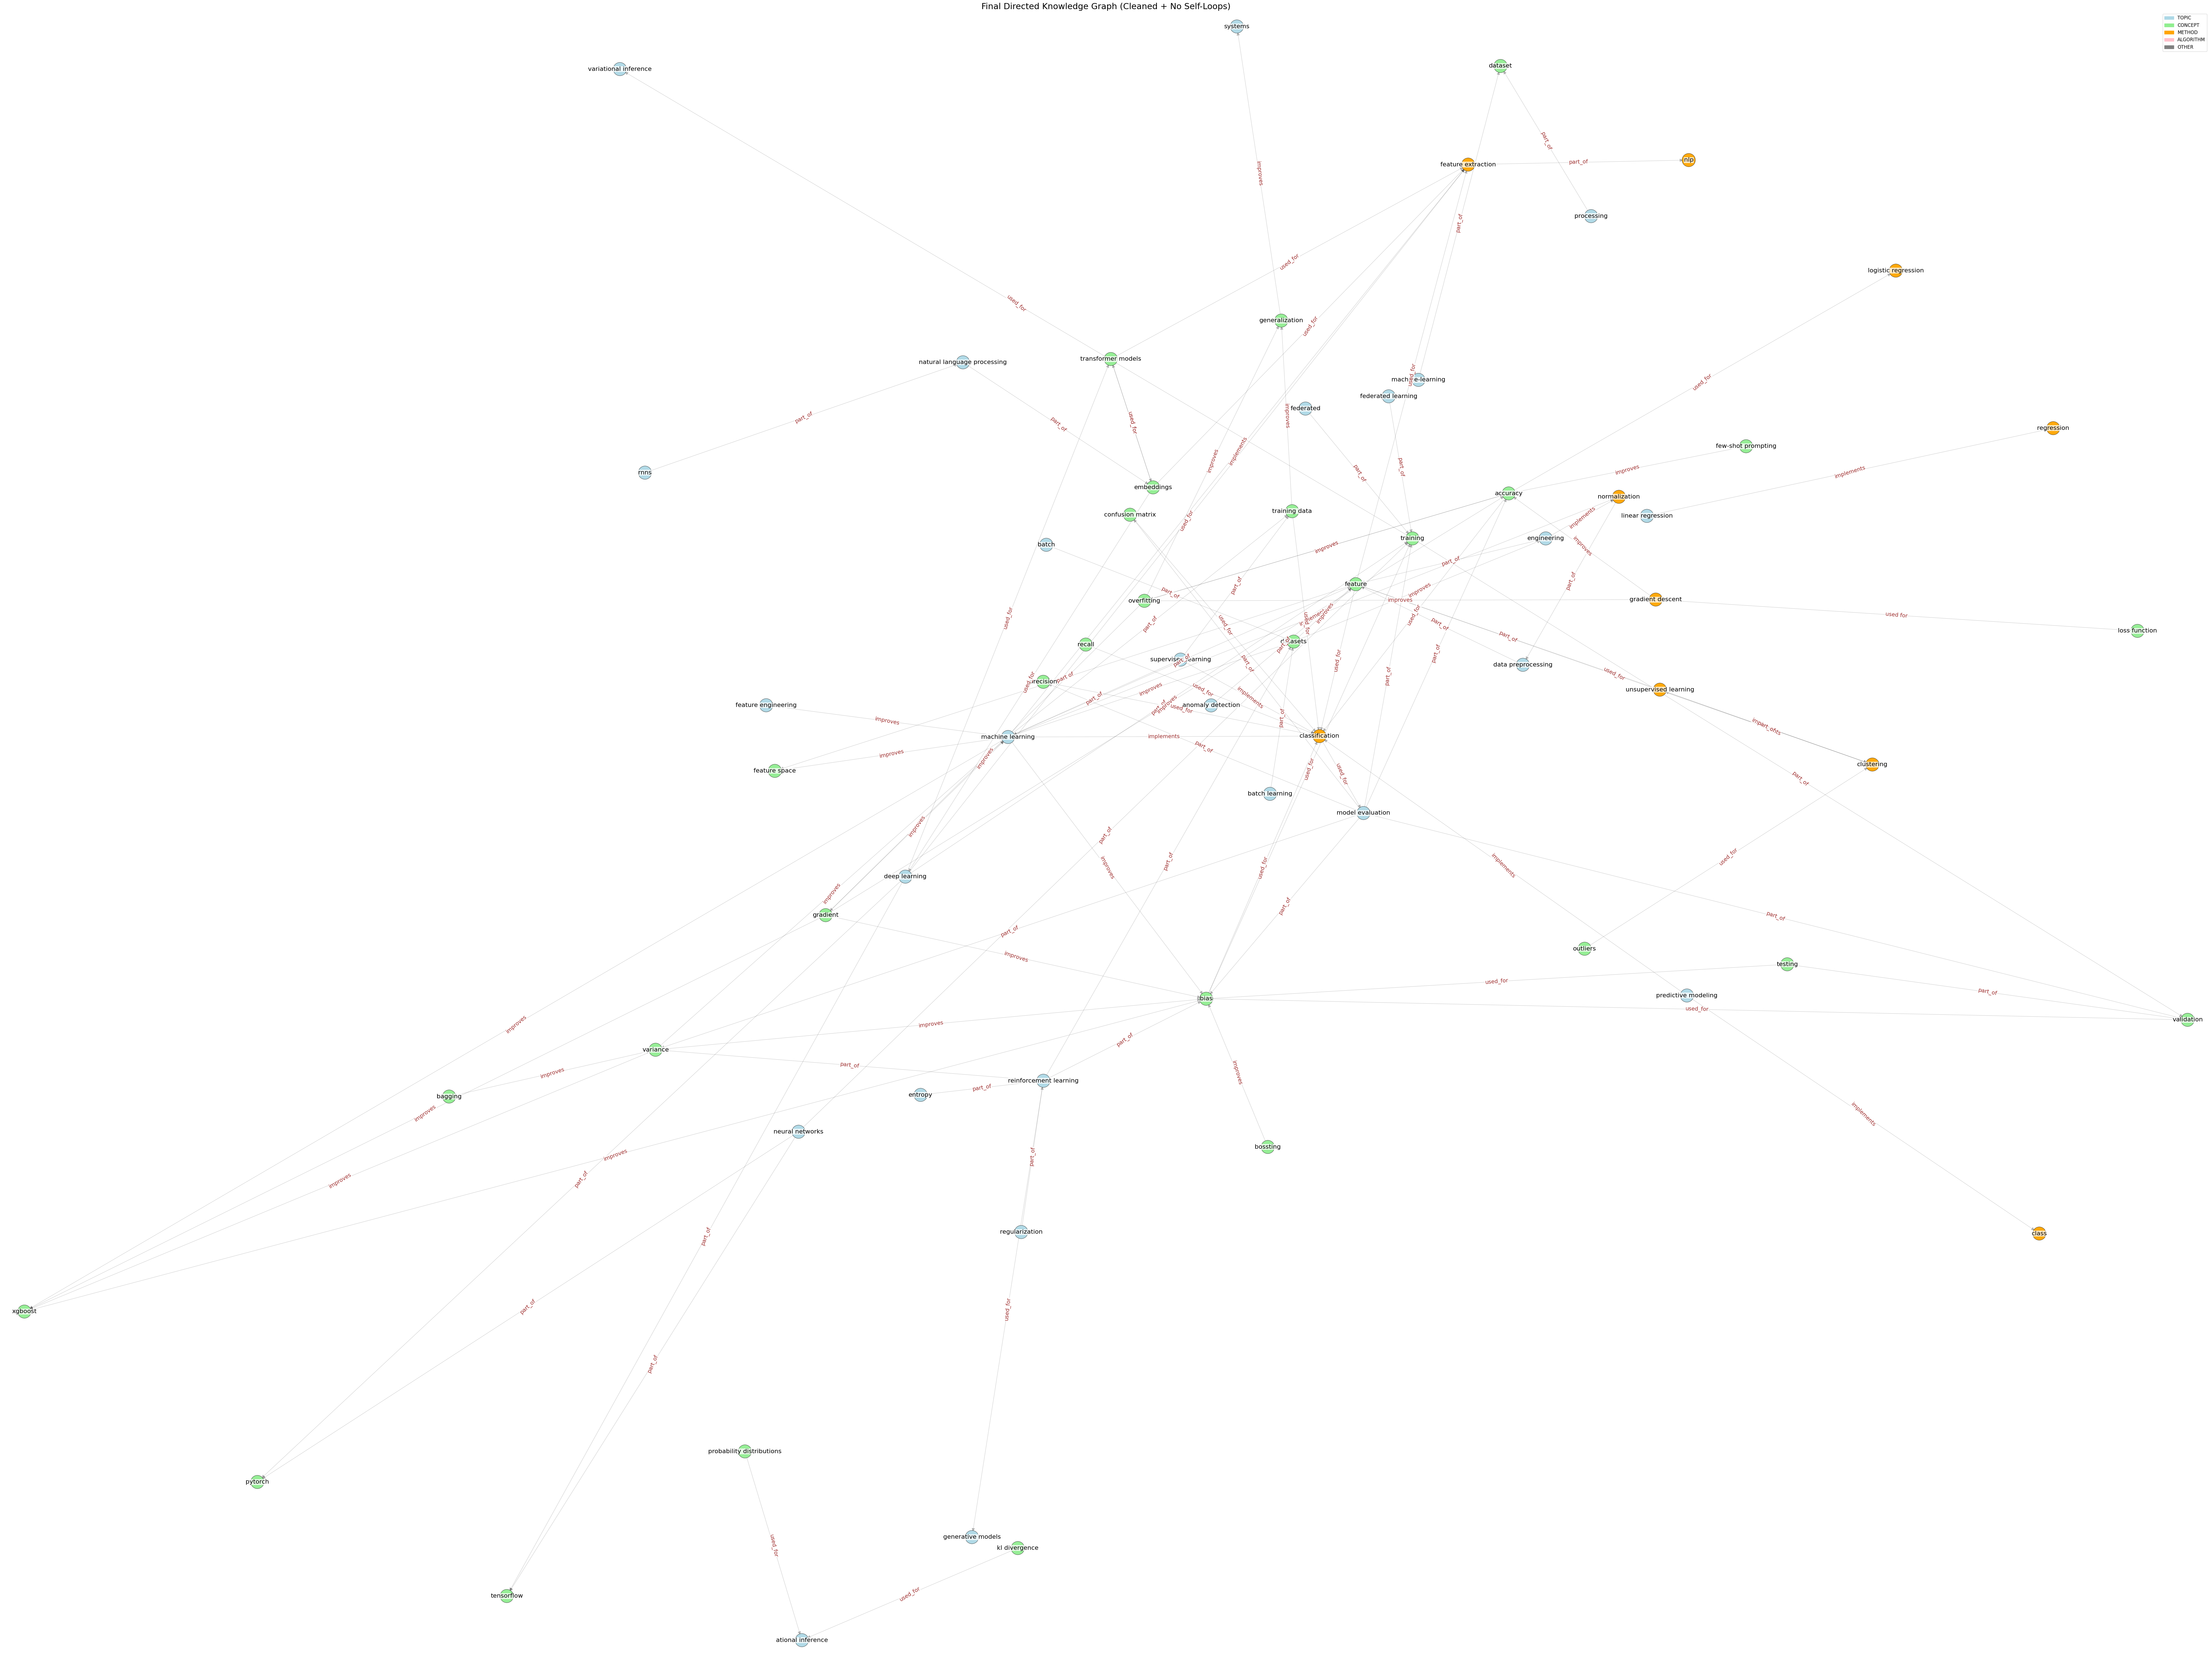

In [21]:
# =========================================
# 1️⃣ IMPORTS
# =========================================
import json
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import math

# =========================================
# 2️⃣ LOAD DATA
# =========================================
with open("/content/final_triplets_level2.json") as f:
    triplets = json.load(f)

# =========================================
# 3️⃣ CLEAN TRIPLETS (VERY IMPORTANT)
# =========================================
clean_triplets = []
self_loops = []

for t in triplets:
    e1 = t["entity1"].strip()
    e2 = t["entity2"].strip()

    # normalize for comparison
    e1_norm = e1.lower()
    e2_norm = e2.lower()

    # ❌ detect self-loop
    if e1_norm == e2_norm:
        self_loops.append(t)
        continue

    clean_triplets.append({
        "entity1": e1,
        "entity2": e2,
        "relation": t["relation"],
        "entity1_type": t["entity1_type"],
        "entity2_type": t["entity2_type"]
    })

print(f"Original triplets: {len(triplets)}")
print(f"Removed self-loops: {len(self_loops)}")
print(f"Remaining triplets: {len(clean_triplets)}")

# OPTIONAL: see problematic ones
for t in self_loops[:10]:
    print("REMOVED:", t)

triplets = clean_triplets

# =========================================
# 4️⃣ BUILD DIRECTED GRAPH
# =========================================
G = nx.DiGraph()

for t in triplets:
    G.add_node(t["entity1"], label=t["entity1_type"])
    G.add_node(t["entity2"], label=t["entity2_type"])
    G.add_edge(t["entity1"], t["entity2"], relation=t["relation"])

# =========================================
# 5️⃣ COLOR MAP
# =========================================
color_map = {
    "TOPIC": "lightblue",
    "CONCEPT": "lightgreen",
    "METHOD": "orange",
    "ALGORITHM": "pink",
    "OTHER": "gray"
}

node_colors = [
    color_map.get(G.nodes[n].get("label", "OTHER"), "gray")
    for n in G.nodes()
]

# =========================================
# 6️⃣ NODE SIZE
# =========================================
node_sizes = [1200 for _ in G.nodes()]

# =========================================
# 7️⃣ LAYOUT (HIGH SPACING)
# =========================================
pos = nx.spring_layout(
    G,
    k=2,
    iterations=500,
    seed=42
)

# expand outward
scale = 6
pos = {k: (v[0]*scale, v[1]*scale) for k, v in pos.items()}

# =========================================
# 8️⃣ DRAW GRAPH
# =========================================
plt.figure(figsize=(80, 60))

# Nodes
nx.draw_networkx_nodes(
    G, pos,
    node_color=node_colors,
    node_size=node_sizes,
    edgecolors="black",
    linewidths=0.6,
    alpha=0.95
)

# Edges
nx.draw_networkx_edges(
    G, pos,
    width=0.7,
    alpha=0.25,
    arrows=True,
    arrowstyle='-|>',
    arrowsize=18,
    edge_color='black',
    min_source_margin=15,
    min_target_margin=15
)

# =========================================
# 9️⃣ NODE LABELS
# =========================================
for node, (x, y) in pos.items():
    plt.text(
        x, y,
        node,
        fontsize=16,
        ha='center',
        va='center',
        bbox=dict(
            facecolor='white',
            alpha=0.75,
            edgecolor='none',
            pad=0.25
        )
    )

# =========================================
# 🔟 EDGE LABELS
# =========================================
for (u, v, d) in G.edges(data=True):
    x1, y1 = pos[u]
    x2, y2 = pos[v]

    mx = (x1 + x2) / 2
    my = (y1 + y2) / 2

    angle = math.degrees(math.atan2(y2 - y1, x2 - x1))
    if angle > 90 or angle < -90:
        angle += 180

    plt.text(
        mx,
        my,
        d["relation"],
        fontsize=14,
        color="darkred",
        alpha=0.8,
        ha='center',
        va='center',
        rotation=angle,
        rotation_mode='anchor',
        bbox=dict(
            facecolor='white',
            alpha=0.8,
            edgecolor='none',
            pad=0.2
        )
    )

# =========================================
# 1️⃣1️⃣ LEGEND
# =========================================
legend_handles = [
    mpatches.Patch(color=color_map[k], label=k)
    for k in color_map
]

plt.legend(handles=legend_handles, loc="upper right", fontsize=12)

# =========================================
# 1️⃣2️⃣ FIT GRAPH TO CANVAS
# =========================================
xs = [x for x, y in pos.values()]
ys = [y for x, y in pos.values()]

margin = 0.1

plt.xlim(min(xs) - margin, max(xs) + margin)
plt.ylim(min(ys) - margin, max(ys) + margin)

# =========================================
# FINAL
# =========================================
plt.title("Final Directed Knowledge Graph (Cleaned + No Self-Loops)", fontsize=22)
plt.axis("off")
plt.margins(0.4)
plt.tight_layout()
plt.show()